# 2. Machine Learning Workflow und Feature Engineering

---
## 2.1 Motivation

In diesem Lab schauen wir uns an, wie wir Rohdaten in ein Format überführen, das Machine-Learning-Modelle verstehen. Wir nutzen den **Titanic-Datensatz** und begleiten ihn von der ersten Inspektion bis hin zu einer fertigen, produktionsreifen `scikit-learn` Pipeline.

**Unsere Werkzeuge:**
* `pandas` für die Datenmanipulation
* `seaborn` und `matplotlib` für Visualisierungen
* `scikit-learn` für die Transformationen und Pipelines

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Imports
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import fetch_openml

# Plot-Style festlegen
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Titanic Datensatz laden (OpenML Version enthält Passagiernamen)
titanic = fetch_openml("titanic", version=1, as_frame=True, parser="auto")
df = titanic.frame

# Wir nutzen eine beschränkte Auswahl an Spalten
cols_to_keep = ['survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = df[cols_to_keep].copy()

# Zielvariable als Integer (0 = nicht überlebt, 1 = überlebt)
df['survived'] = df['survived'].astype(int)

df.head()

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,211.3375,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,151.5500,S
2,0,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,151.5500,S
3,0,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,151.5500,S
4,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,151.5500,S


## 2.1 Datenexploration (EDA) und fehlende Werte

Bevor wir etwas verändern, müssen wir unsere Daten verstehen. Wo fehlen eventuell Daten? Ein Modell kann mit einem "NaN" (Not a Number) Wert nichts anfangen.

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  1309 non-null   int64   
 1   pclass    1309 non-null   int64   
 2   name      1309 non-null   str     
 3   sex       1309 non-null   category
 4   age       1046 non-null   float64 
 5   sibsp     1309 non-null   int64   
 6   parch     1309 non-null   int64   
 7   fare      1308 non-null   float64 
 8   embarked  1307 non-null   category
dtypes: category(2), float64(2), int64(4), str(1)
memory usage: 74.3 KB
None


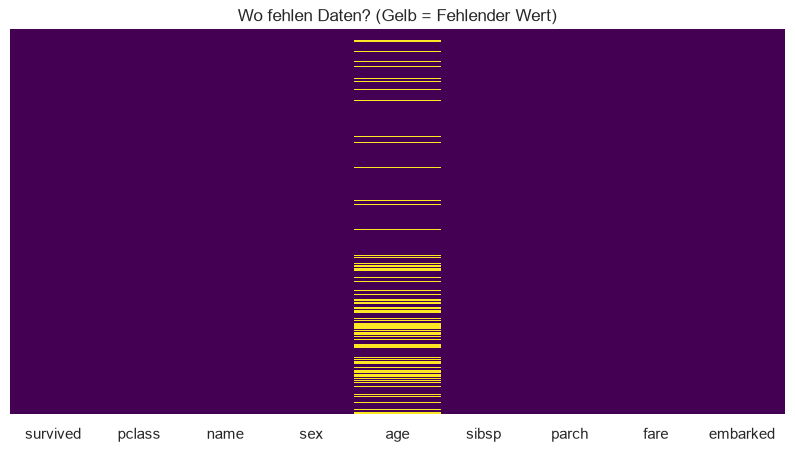

In [34]:
# Überblick über Datentypen und fehlende Werte
print(df.info())

# Visualisierung der fehlenden Werte
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Wo fehlen Daten? (Gelb = Fehlender Wert)")
plt.show()

## 2.2 Der Train-Test-Split (Schutz vor Data Leakage)

> **Achtung:** Wir teilen unsere Daten auf, *bevor* wir fehlende Werte auffüllen oder skalieren! 

Warum? Wenn wir z.B. das Durchschnittsalter aller Passagiere berechnen, um Lücken zu füllen, und die Testdaten dabei einschließen, fließen Informationen aus den Testdaten in unser Trainingstraining ein → sog. **Data Leakage**

In [35]:
# X sind unsere Features, y ist unsere Zielvariable (Target)
X = df.drop('survived', axis=1)
y = df['survived']

# 80% Training, 20% Test. random_state sorgt für Reproduzierbarkeit.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Trainingsdaten: {X_train.shape[0]} Zeilen")
print(f"Testdaten: {X_test.shape[0]} Zeilen")

Trainingsdaten: 1047 Zeilen
Testdaten: 262 Zeilen


## 2.3 Imputation (Fehlende Werte behandeln)

Wir haben gesehen, dass der Wert Alter (`age`) häufig fehlt. Wie füllen wir diese Lücken auf? Welche Imputationsmethoden gibt es?

Um Ausreißer nicht zu stark zu gewichten, nutzen wir den **Median** statt des Durchschnitts (Mean).

> **Achtung:** `fit()` lernen wir nur auf den Trainingsdaten, `transform()` wenden wir auf Train und Test an.

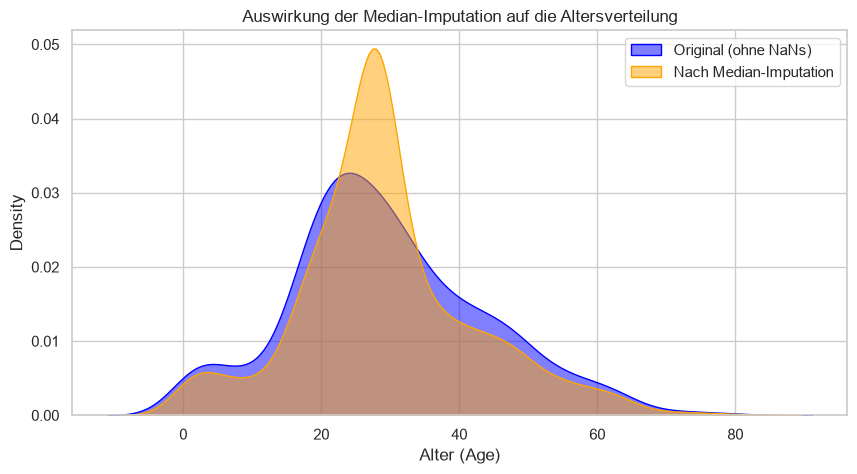

In [36]:
# Imputer initialisieren
imputer_age = SimpleImputer(strategy='median')

# Kopie erstellen, um das Original für spätere Schritte nicht zu überschreiben
X_train_imp = X_train.copy()

# 1. FIT (Median lernen) & TRANSFORM (Lücken füllen) auf Trainingsdaten
X_train_imp['age'] = imputer_age.fit_transform(X_train[['age']])

# Visualisierung: Wie verändert die Imputation die Verteilung?
plt.figure(figsize=(10, 5))
sns.kdeplot(X_train['age'].dropna(), label='Original (ohne NaNs)', fill=True, color='blue', alpha=0.5)
sns.kdeplot(X_train_imp['age'], label='Nach Median-Imputation', fill=True, color='orange', alpha=0.5)
plt.title("Auswirkung der Median-Imputation auf die Altersverteilung")
plt.xlabel("Alter (Age)")
plt.legend()
plt.show()

> **Wiederholung**: Welche Strategien zum Umgang mit fehlenden Werten gibt es?

* Ignorieren / Entfernen: 
    - Listwise Deletion
    - Pairwise Deletion
* Imputation: 
    - Mean / Median Imputation 
    - Regression Imputation
    - KNN-Imputation 
    - Multiple Imputation 
    - Model-based Imputation
    - Indicator Encoding

## 2.4 Feature Scaling 

Modelle wie Logistische Regression oder Neuronale Netze reagieren empfindlich auf unterschiedliche Skalen (z.B. Alter geht von 0-80, Ticketpreise `fare` von 0-500). Wir müssen sie angleichen.

Der Ticketpreis (`fare`) beim Titanic-Datensatz ist extrem rechtsschief (viele günstige Tickets, einige wenige extrem teure). Wir vergleichen nun zwei Ansätze:
1. **StandardScaler:** Nutzt den Mittelwert und die Standardabweichung.
2. **RobustScaler:** Nutzt den Median und die Quartile (ignoriert Ausreißer weitgehend).

**Teil 1: Boxplots**
Wenn wir die Boxplots der skalierten Daten einzeln betrachten, scheinen sie sich in ihrer Form nicht verändert zu haben. Das liegt daran, dass Skalierung die Verteilung nicht verändert – matplotlib passt lediglich die Zahlen auf der y-Achse an!


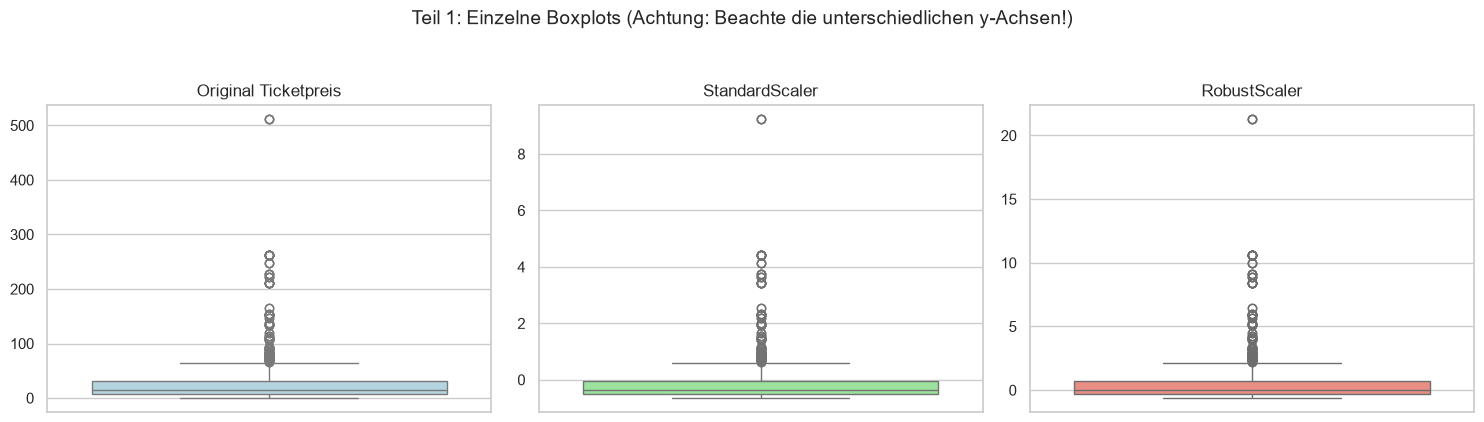

In [37]:
# Lücken im Ticketpreis füllen (Median)
imputer_fare = SimpleImputer(strategy='median')
fare_train = imputer_fare.fit_transform(X_train[['fare']])

# Scaler anwenden
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

fare_std = std_scaler.fit_transform(fare_train)
fare_rob = rob_scaler.fit_transform(fare_train)

# ==========================================
# TEIL 1: Boxplots
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# WICHTIG: .flatten() macht aus dem 2D-Array ein 1D-Array für Seaborn
sns.boxplot(y=fare_train.flatten(), ax=axes[0], color='lightblue')
axes[0].set_title('Original Ticketpreis')

sns.boxplot(y=fare_std.flatten(), ax=axes[1], color='lightgreen')
axes[1].set_title('StandardScaler')

sns.boxplot(y=fare_rob.flatten(), ax=axes[2], color='salmon')
axes[2].set_title('RobustScaler')

plt.suptitle("Teil 1: Einzelne Boxplots (Achtung: Beachte die unterschiedlichen y-Achsen!)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()



**Teil 2: Kernel Density Estimation (KDE)**
Legen wir die skalierten Daten aber im selben Dichte-Plot (KDE) übereinander und zoomen hinein, sehen wir das Problem des `StandardScaler`s: Die extrem reichen Passagiere ziehen den Mittelwert so stark nach oben, dass die große Masse der normalen Passagiere beim Zentrieren tief in den negativen Bereich gedrückt wird. Der `RobustScaler` hingegen zentriert den Hauptteil der Passagiere perfekt auf der 0.

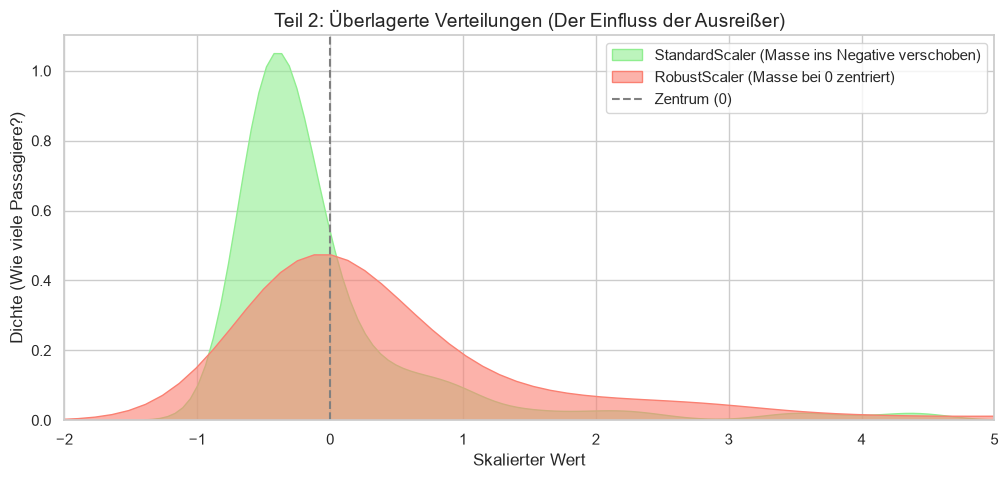

In [38]:
# ==========================================
# TEIL 2: KDE Dichte-Plot
# ==========================================
plt.figure(figsize=(12, 5))

# sns.kdeplot(fare_train.flatten(), label='Original', fill=True, color='lightblue', alpha=0.6) # kaum erkennbar im gezeigten Ausschnitt
sns.kdeplot(fare_std.flatten(), label='StandardScaler (Masse ins Negative verschoben)', fill=True, color='lightgreen', alpha=0.6)
sns.kdeplot(fare_rob.flatten(), label='RobustScaler (Masse bei 0 zentriert)', fill=True, color='salmon', alpha=0.6)

plt.title("Teil 2: Überlagerte Verteilungen (Der Einfluss der Ausreißer)", fontsize=14)
plt.xlabel("Skalierter Wert")
plt.ylabel("Dichte (Wie viele Passagiere?)")

# Wir zoomen auf den Hauptbereich (-2 bis 5), um die extremen Ausreißer rechts abzuschneiden
plt.xlim(-2, 5) 

# Eine Hilfslinie bei 0 einzeichnen
plt.axvline(0, color='gray', linestyle='--', label='Zentrum (0)')

plt.legend()
plt.show()

> **Wiederholung**: Bei welchen Methoden ist eine Skalierung erforderlich?

* Distanzbasierten Methoden: k-NN, k-Means, SVM (RBF)
* Gradient-Descent-basierten Modellen: lineare / *logistische Regression*, NN

> Bei welchen Methoden ist eine Skalierung **nicht** erforderlich?
* Baum-basierten Verfahren: Decision Tree, Random Forest, XGBoost
* Reine Zählmerkmale (z. B. One-Hot-Encoded Variablen)

## 2.5 Kategorien Encoden (Text zu Zahlen)

Modelle können nicht rechnen mit "male" oder "female" oder Abfahrtsorten wie "S" (Southampton). Wir übersetzen dies mit dem **One-Hot-Encoder**. Er erstellt für jede Kategorie eine eigene Spalte mit 0 oder 1.

In [39]:
# Lücken im Abfahrtsort mit dem häufigsten Wert (mode) füllen
X_train_imp['embarked'] = X_train_imp['embarked'].fillna(X_train_imp['embarked'].mode()[0])

# One-Hot-Encoder (drop='first' verhindert Multikollinearität / Dummy Variable Trap)
ohe = OneHotEncoder(drop='first', sparse_output=False)

# Anwenden auf Geschlecht und Abfahrtsort
encoded_cols = ohe.fit_transform(X_train_imp[['sex', 'embarked']])
encoded_df = pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(['sex', 'embarked']))

encoded_df.head()

,sex_male,embarked_Q,embarked_S
0,1.0,0.0,1.0
1,1.0,0.0,1.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,1.0,0.0,1.0


## 2.6 Feature Engineering

Hier bringen wir Domänenwissen ein. Manchmal sind die rohen Features nicht aussagekräftig genug. 

**Beispiel 1: Text-Extraktion.** Der Name an sich bringt dem Modell wenig, da er fast für jeden Passagier einzigartig ist. Aber der *Titel* (Mr., Mrs., Rev., Dr.) verrät viel über den sozialen Status!

**Beispiel 2: Log-Transformation.** Die Ticketpreise schwanken extrem. Eine Logarithmus-Transformation drückt diese riesige Spannweite in eine normalverteilungs-ähnlichere Form. Dadurch können die Daten in linearen Modellen besser interpretiert werden.

Gefundene Titel:
title
Mr        604
Miss      210
Mrs       153
Master     50
Rev         8
Name: count, dtype: int64 



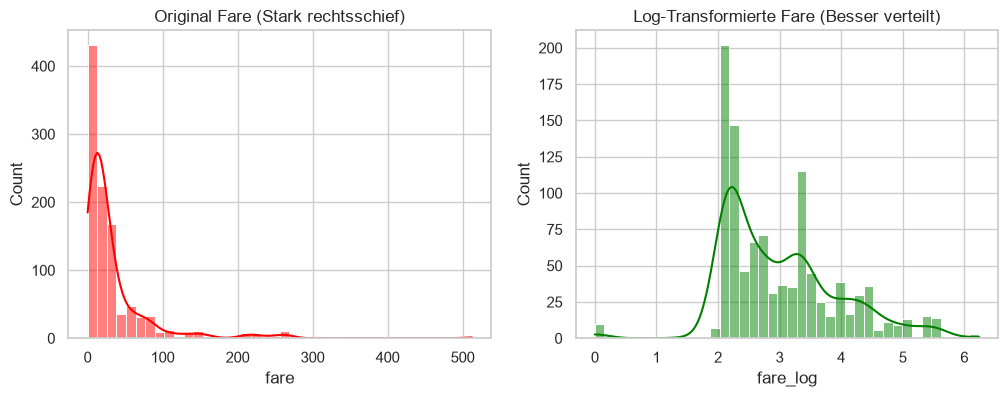

In [40]:
# 1. Text Extraktion: Titel aus dem Namen parsen via Regex
X_train_imp['title'] = X_train['name'].str.extract(' ([A-Za-z]+)\.', expand=False)
print("Gefundene Titel:")
print(X_train_imp['title'].value_counts().head() , "\n")

# 2. Log-Transformation auf Fare (wir addieren 1, um log(0) zu vermeiden)
X_train_imp['fare_log'] = np.log1p(X_train_imp['fare'].fillna(X_train_imp['fare'].median()))

# Visualisierung Log-Transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_train_imp['fare'], bins=40, ax=axes[0], kde=True, color='red')
axes[0].set_title('Original Fare (Stark rechtsschief)')

sns.histplot(X_train_imp['fare_log'], bins=40, ax=axes[1], kde=True, color='green')
axes[1].set_title('Log-Transformierte Fare (Besser verteilt)')
plt.show()

### Exkurs: Polynomial Features (Tool für Nichtlinearitäten)

Manchmal ist der Zusammenhang zwischen einem Feature und der Vorhersage nicht linear. Der Titanic-Datensatz verzeiht vieles, daher schauen wir uns dieses Prinzip kurz an simulierten, "krummen" Daten an. 

Wir bauen ein parabelförmiges Problem. Ein einfaches lineares Modell wird kläglich scheitern. Fügen wir aber als Feature $x^2$ (Polynomial Feature) hinzu, "biegt" sich das lineare Modell perfekt an die Kurve an!

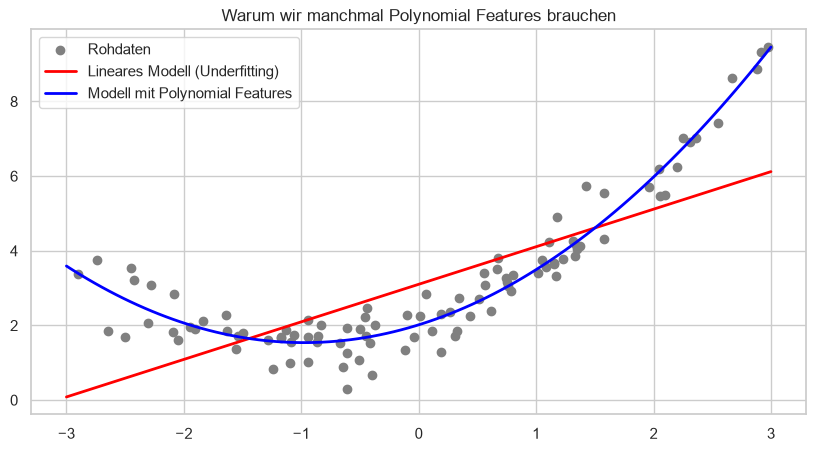

In [41]:
# Synthetische Daten erzeugen (Parabel y = X^2 + Rauschen)
np.random.seed(123)
X_syn = np.random.uniform(-3, 3, 100).reshape(-1, 1)
y_syn = 0.5 * X_syn**2 + X_syn + 2 + np.random.randn(100, 1) * 0.5

# 1. Normales Lineares Modell trainieren
lin_reg = LinearRegression()
lin_reg.fit(X_syn, y_syn)
X_plot = np.linspace(-3, 3, 100).reshape(-1, 1)
y_pred_lin = lin_reg.predict(X_plot)

# 2. Polynomial Features erzeugen (Grad 2)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X_syn)

# Lineares Modell auf den transformierten (polynomialen) Daten trainieren
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y_syn)
y_pred_poly = poly_reg.predict(poly_features.transform(X_plot))

# Visualisierung
plt.figure(figsize=(10, 5))
plt.scatter(X_syn, y_syn, color='gray', label='Rohdaten')
plt.plot(X_plot, y_pred_lin, color='red', linewidth=2, label='Lineares Modell (Underfitting)')
plt.plot(X_plot, y_pred_poly, color='blue', linewidth=2, label='Modell mit Polynomial Features')
plt.title("Warum wir manchmal Polynomial Features brauchen")
plt.legend()
plt.show()

* Beispiel 1 ($Age^2$): Ein lineares Modell folgt der Annahme: Je älter (oder jünger), desto höher/niedriger die Überlebenschance (eine gerade Linie, hier: rot). Im *Titanic* Kontext ist diese Annahme falsch. Kleinkinder (sehr jung) hatten eine extrem hohe Überlebenschance. Junge Erwachsene (20-30 Jahre) hatten eine recht schlechte Überlebenschance. Ältere Passagiere der 1. Klasse wiederum hatten bessere Chancen. 
→ Ein lineares Modell scheitert hier. Polynomial Features der 2. Ordnung (z.B. Alter im Quadrat $Age^2$) führen dazu, dass das Modell die Möglichkeit hat eine "U-Kurve" zu erlernen. Damit kann diese nicht-lineare Beziehung zwischen Alter-Überleben besser abgebildet werden.

* Beispiel 2 ($Age \times Pclass$): Im Titanic-Datensatz würde ein Polynomial Feature wie $Age \times Pclass$ (Interaktionsterm) unserem linearen Modell helfen zu verstehen, dass es ein riesiger Unterschied war, ob man ein Kind (geringer Alterswert) in der 1. Klasse oder ein Kind in der 3. Klasse war.

## 2.7 Best Practice: Scikit-Learn Pipelines

Unsere Vorgehensweise bis hier hin ist fehleranfällig (diente aber zum Verständnis): Wenn wir aber neue, ungesehene Daten bekommen, müssten wir alle Imputer, Scaler und Encoder in genau der richtigen Reihenfolge erneut manuell aufrufen. 

Wir lösen dieses Problem mit **Pipelines** und dem **ColumnTransformer**. So definieren wir *einmal* den Bauplan.

In [42]:
# Features nach Typen sortieren
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['sex', 'embarked', 'pclass'] # Pclass ist zwar eine Zahl, aber eigentlich kategorial

# Pipeline für numerische Werte (Fehlende füllen -> Skalieren)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline für kategoriale Werte (Fehlende füllen -> One-Hot-Encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # handle_unknown schützt vor neuen Kategorien in Testdaten
])

# Zusammenführen der Pipelines im ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Komplette Modell-Pipeline (Preprocessing + Logistische Regression)
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# !!! Aufrufen von .fit() lernt alle Imputer, Scaler, Encoder und trainiert das Modell!
clf_pipeline.fit(X_train, y_train)

# !!! Aufrufen von .predict() auf ungesehenen Daten schleust diese automatisch durch alle Schritte!
y_pred = clf_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Pipeline erfolgreich trainiert!")
print(f"Genauigkeit (Accuracy) auf Testdaten: {acc * 100:.2f}%")

Pipeline erfolgreich trainiert!
Genauigkeit (Accuracy) auf Testdaten: 77.48%
